# Model Comparison Notebook

This notebook reads the saved results from every standalone model notebook and produces fair side-by-side comparison plots and summary tables.


## Run Safety

Before running this notebook, restart the kernel.

Why this matters:
- previous model runs can leave tensors and cached arrays in memory
- old variables can leak into the current run and make comparisons unfair
- we want every notebook to save a clean, reproducible result

Recommended workflow:
1. Restart kernel
2. Run all cells from top to bottom
3. Let the notebook save its outputs before closing it


In [1]:
# Memory cleanup before starting this notebook.
import gc

gc.collect()
try:
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
except Exception:
    pass

print('Kernel memory cleanup complete. Start the notebook from here after a restart.')


Kernel memory cleanup complete. Start the notebook from here after a restart.


In [2]:
# Standard-library imports used throughout the evaluation notebooks.
import json
import math
import random
from collections import Counter
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from datetime import datetime
from IPython.display import display

# Core scientific / ML stack.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset

# ROC / PR curves are useful for classification comparison if sklearn is available.
try:
    from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
    from sklearn.preprocessing import label_binarize
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

# Resolve the project root robustly no matter where Jupyter was launched from.
SEARCH_ROOT = Path.cwd().resolve()
PROJECT_ROOT = SEARCH_ROOT
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / '04_model_evaluation').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EVAL_ROOT = PROJECT_ROOT / '04_model_evaluation'
THESIS_ROOT = EVAL_ROOT
NOTEBOOK_ROOT = EVAL_ROOT / 'notebooks'
RESULTS_ROOT = EVAL_ROOT / 'results'
WEIGHTS_ROOT = EVAL_ROOT / 'model_weights'
SPLITS_ROOT = EVAL_ROOT / 'splits'
PLOTS_ROOT = EVAL_ROOT / 'plots'
ORIGINAL_DATASET_ROOT = PROJECT_ROOT / '03_dataset' / 'hybrid_maneuver_dataset'
PREFERRED_DATASET_ROOT = Path('/media/basudeo/1044063744061FD8/hybrid_maneuver_dataset')
DATASET_ROOT = PREFERRED_DATASET_ROOT if PREFERRED_DATASET_ROOT.exists() else ORIGINAL_DATASET_ROOT

print('Project root:', PROJECT_ROOT)
print('Evaluation workspace:', THESIS_ROOT)
print('Original dataset root:', ORIGINAL_DATASET_ROOT)
print('Preferred external dataset root:', PREFERRED_DATASET_ROOT)
print('Dataset root:', DATASET_ROOT)
print('Torch version:', torch.__version__)
print('Sklearn available for ROC/PR plots:', SKLEARN_AVAILABLE)


Project root: /home/basudeo/Documents/Thesis
Evaluation workspace: /home/basudeo/Documents/Thesis/04_model_evaluation
Original dataset root: /home/basudeo/Documents/Thesis/03_dataset/hybrid_maneuver_dataset
Preferred external dataset root: /media/basudeo/1044063744061FD8/hybrid_maneuver_dataset
Dataset root: /home/basudeo/Documents/Thesis/03_dataset/hybrid_maneuver_dataset
Torch version: 2.3.1+cu118
Sklearn available for ROC/PR plots: True


In [3]:
MODEL_SLUGS = [
    'cv_baseline',
    'cnn_lstm',
    'gnn_lstm',
    'cnn_gnn_lstm',
    'cnn_gnn_transformer',
    'cnn_gnn_lstm_transformer',
]

summary_rows = []
latest_metrics = {}
for slug in MODEL_SLUGS:
    latest_metrics_path = RESULTS_ROOT / slug / 'latest_metrics.json'
    if latest_metrics_path.exists():
        with latest_metrics_path.open() as f:
            payload = json.load(f)
        latest_metrics[slug] = payload
        payload['model'] = slug
        summary_rows.append(payload)

summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    raise RuntimeError('No latest_metrics.json files were found. Run the model notebooks first.')

display(summary_df)
print(summary_df.to_string())


,ADE,FDE,RMSE,split_path,trajectory_overlay_plots,mean_step_error_plot,trajectory_prediction_file,status,model,loss,best_val_ADE,accuracy,macro_precision,macro_recall,macro_f1,confusion_matrix,best_val_macro_f1,roc_auc_macro,pr_auc_macro
0,17.986391,27.877451,56.989902,/home/basudeo/Documents/Thesis/04_model_evalua...,[/home/basudeo/Documents/Thesis/04_model_evalu...,/home/basudeo/Documents/Thesis/04_model_evalua...,/home/basudeo/Documents/Thesis/04_model_evalua...,saved,cv_baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16.908745,26.110857,56.972839,/home/basudeo/Documents/Thesis/04_model_evalua...,[/home/basudeo/Documents/Thesis/04_model_evalu...,/home/basudeo/Documents/Thesis/04_model_evalua...,/home/basudeo/Documents/Thesis/04_model_evalua...,saved,cnn_lstm,1622.952289,16.973776,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,/home/basudeo/Documents/Thesis/Thesis_Repo/spl...,NaN,NaN,NaN,saved,gnn_lstm,1.242015,NaN,0.692708,0.299731,0.398276,0.341404,"[[115, 0, 1, 0, 0], [6, 0, 0, 0, 0], [7, 0, 0,...",0.362033,0.77341,0.511248
3,17.454792,23.088606,45.043346,/home/basudeo/Documents/Thesis/04_model_evalua...,[/home/basudeo/Documents/Thesis/04_model_evalu...,/home/basudeo/Documents/Thesis/04_model_evalua...,/home/basudeo/Documents/Thesis/04_model_evalua...,saved,cnn_gnn_lstm,1014.451620,17.900723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,16.826502,21.815641,47.966782,/home/basudeo/Documents/Thesis/04_model_evalua...,[/home/basudeo/Documents/Thesis/04_model_evalu...,/home/basudeo/Documents/Thesis/04_model_evalua...,/home/basudeo/Documents/Thesis/04_model_evalua...,saved,cnn_gnn_transformer,1150.406045,17.432257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,16.100689,21.834784,48.524475,/home/basudeo/Documents/Thesis/04_model_evalua...,[/home/basudeo/Documents/Thesis/04_model_evalu...,/home/basudeo/Documents/Thesis/04_model_evalua...,/home/basudeo/Documents/Thesis/04_model_evalua...,saved,cnn_gnn_lstm_transformer,1177.312229,15.856398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


         ADE        FDE       RMSE                                                                                                        split_path                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [4]:
# Save a clean summary table for thesis reporting.
comparison_csv = THESIS_ROOT / 'comparison_exports' / 'model_summary_latest.csv'
comparison_json = THESIS_ROOT / 'comparison_exports' / 'model_summary_latest.json'
summary_df.to_csv(comparison_csv, index=False)
comparison_json.write_text(summary_df.to_json(orient='records', indent=2))
print('Saved comparison CSV:', comparison_csv)
print('Saved comparison JSON:', comparison_json)


Saved comparison CSV: /home/basudeo/Documents/Thesis/04_model_evaluation/comparison_exports/model_summary_latest.csv
Saved comparison JSON: /home/basudeo/Documents/Thesis/04_model_evaluation/comparison_exports/model_summary_latest.json


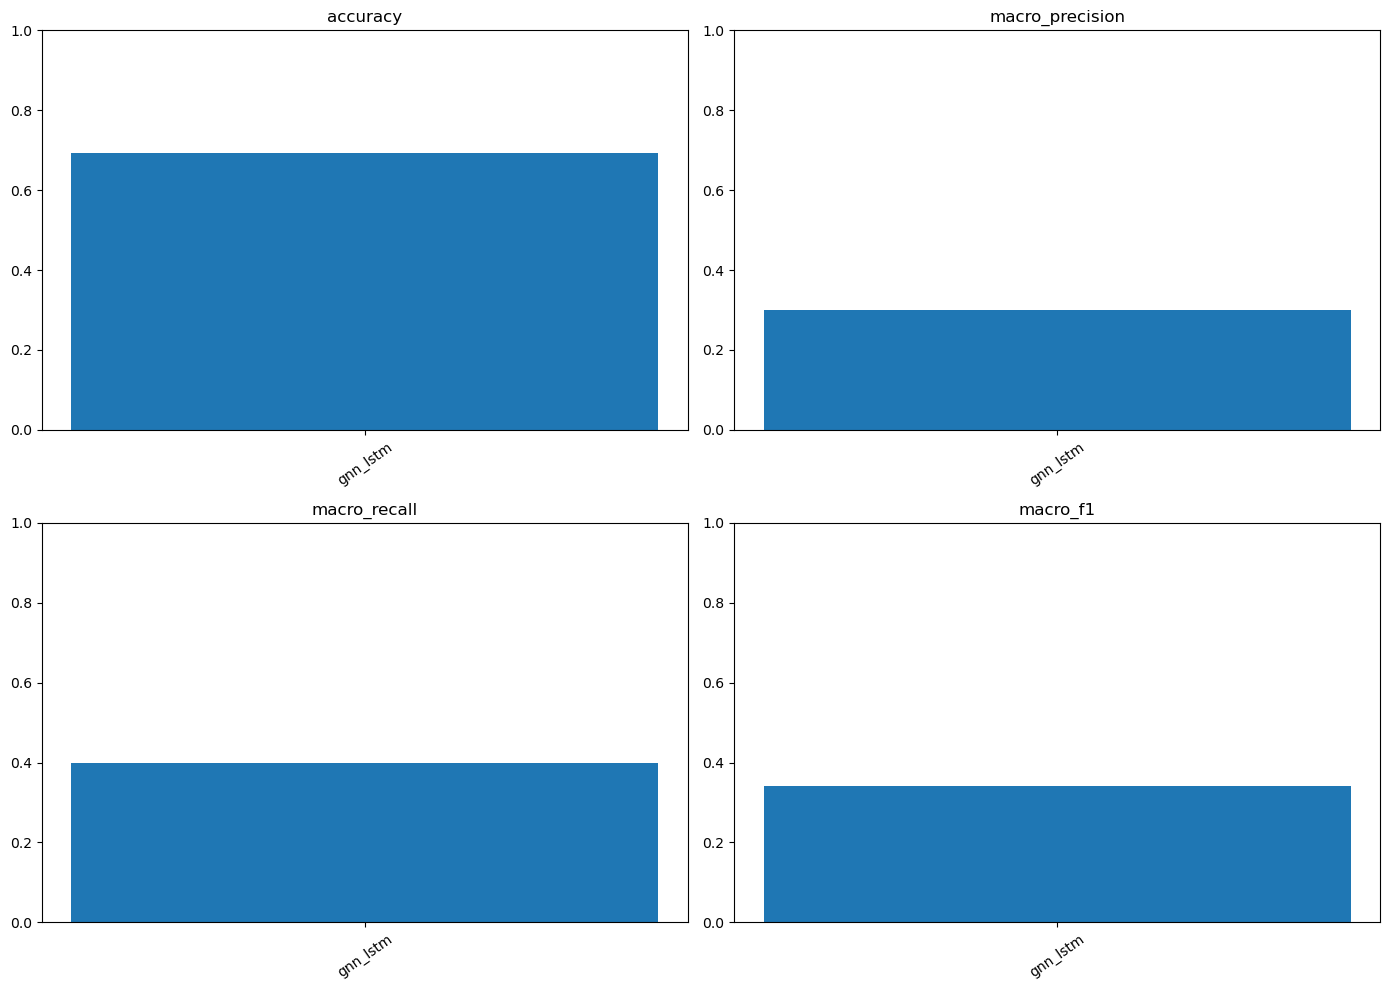

Saved: /home/basudeo/Documents/Thesis/04_model_evaluation/plots/comparison_metrics_bar.png


In [5]:
# Core classification metrics bar chart.
plot_metrics = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flatten(), plot_metrics):
    ordered = summary_df.sort_values(metric, ascending=False)
    ax.bar(ordered['model'], ordered[metric])
    ax.set_title(metric)
    ax.set_ylim(0.0, 1.0)
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
out_path = THESIS_ROOT / 'plots' / 'comparison_metrics_bar.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


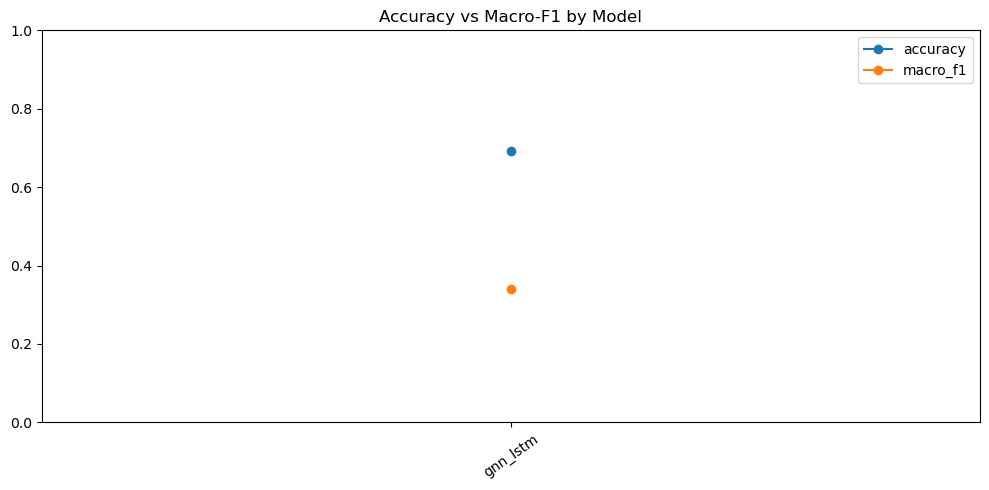

Saved: /home/basudeo/Documents/Thesis/04_model_evaluation/plots/comparison_accuracy_macro_f1.png


In [6]:
# Compare macro-F1 and accuracy together as a line plot.
ordered = summary_df.sort_values('macro_f1', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ordered['model'], ordered['accuracy'], marker='o', label='accuracy')
ax.plot(ordered['model'], ordered['macro_f1'], marker='o', label='macro_f1')
ax.set_ylim(0.0, 1.0)
ax.set_title('Accuracy vs Macro-F1 by Model')
ax.legend()
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
out_path = THESIS_ROOT / 'plots' / 'comparison_accuracy_macro_f1.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


,model,ADE,FDE,RMSE
0,cv_baseline,17.986391,27.877451,56.989902
1,cnn_lstm,16.908745,26.110857,56.972839
2,gnn_lstm,NaN,NaN,NaN
3,cnn_gnn_lstm,17.454792,23.088606,45.043346
4,cnn_gnn_transformer,16.826502,21.815641,47.966782
5,cnn_gnn_lstm_transformer,16.100689,21.834784,48.524475


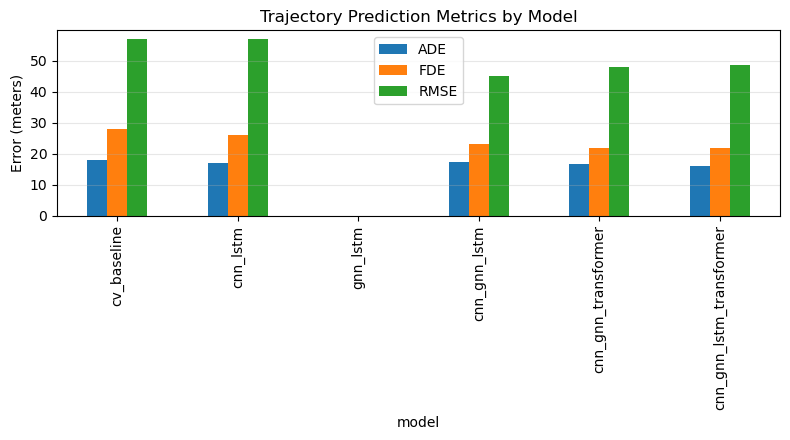

Saved trajectory comparison plot to /home/basudeo/Documents/Thesis/04_model_evaluation/plots/trajectory_metric_comparison.png


In [7]:
# Compare ADE / FDE / RMSE across models when trajectory-aware notebooks save them.
trajectory_metrics = ['ADE', 'FDE', 'RMSE']
trajectory_df = summary_df[['model']].copy()
for key in trajectory_metrics:
    trajectory_df[key] = summary_df[key] if key in summary_df.columns else np.nan

display(trajectory_df)

if not trajectory_df[trajectory_metrics].isna().all().all():
    plot_df = trajectory_df.set_index('model')
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_df.plot(kind='bar', ax=ax)
    ax.set_ylabel('Error (meters)')
    ax.set_title('Trajectory Prediction Metrics by Model')
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    out_path = PLOTS_ROOT / 'trajectory_metric_comparison.png'
    fig.savefig(out_path, dpi=180)
    plt.show()
    print('Saved trajectory comparison plot to', out_path)
else:
    print('No ADE/FDE/RMSE values found yet in the latest metric files.')


In [8]:
# Pull the latest confusion matrices when available.
for slug in MODEL_SLUGS:
    latest_confusions = sorted((RESULTS_ROOT / slug).glob('confusion_*.csv'))
    if not latest_confusions:
        continue
    print('Latest confusion matrix for', slug)
    display(pd.read_csv(latest_confusions[-1], index_col=0))


Latest confusion matrix for cv_baseline


,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,91,33,14,5,0
avoid_left,0,13,1,0,0
avoid_right,0,1,17,0,0
commit_forward,6,48,22,2,0
arrived,35,0,0,0,0


Latest confusion matrix for cnn_lstm


,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,143,0,0,0,0
avoid_left,14,0,0,0,0
avoid_right,18,0,0,0,0
commit_forward,78,0,0,0,0
arrived,35,0,0,0,0


Latest confusion matrix for gnn_lstm


...

,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,77,0,0,11,55
avoid_left,4,0,0,2,8
avoid_right,8,0,0,6,4
commit_forward,28,0,0,9,41
arrived,0,0,0,3,32


Latest confusion matrix for cnn_gnn_transformer


,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,340,29,2,14,4
avoid_left,10,13,1,3,0
avoid_right,9,4,3,3,0
commit_forward,57,8,4,27,2
arrived,0,0,0,0,77


Latest confusion matrix for cnn_gnn_lstm_transformer


,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,333,21,2,29,4
avoid_left,10,15,0,2,0
avoid_right,9,4,4,2,0
commit_forward,52,1,12,32,1
arrived,0,0,0,2,75


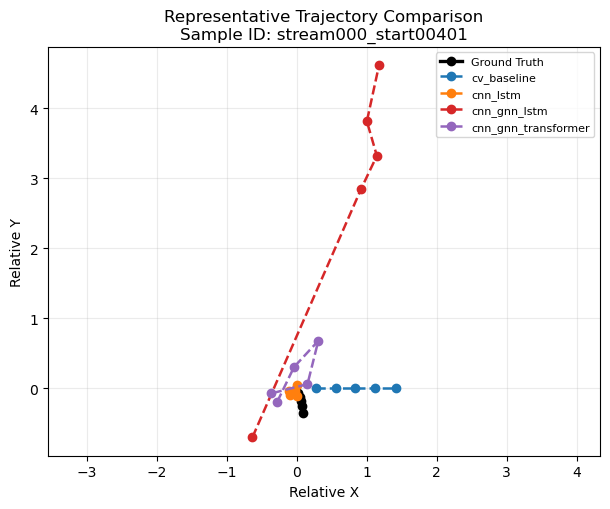

Saved: /home/basudeo/Documents/Thesis/04_model_evaluation/plots/trajectory_shared_sample_comparison.png


In [9]:
# Shared-sample trajectory line comparison across models.
trajectory_exports = {}
for slug in MODEL_SLUGS:
    npz_path = RESULTS_ROOT / slug / 'latest_trajectory_predictions.npz'
    if npz_path.exists():
        payload = np.load(npz_path, allow_pickle=False)
        trajectory_exports[slug] = {
            'sample_ids': payload['sample_ids'].astype(str),
            'pred_future_xy': payload['pred_future_xy'],
            'true_future_xy': payload['true_future_xy'],
        }

if len(trajectory_exports) < 2:
    print('Not enough trajectory export files found yet. Re-run the final evaluation cells of the model notebooks first.')
else:
    common_ids = None
    for slug, payload in trajectory_exports.items():
        ids = set(payload['sample_ids'].tolist())
        common_ids = ids if common_ids is None else common_ids.intersection(ids)

    if not common_ids:
        print('No shared sample_id found across the saved trajectory exports.')
    else:
        common_ids = sorted(common_ids)
        best_slug = 'cnn_gnn_lstm_transformer' if 'cnn_gnn_lstm_transformer' in trajectory_exports else next(iter(trajectory_exports))
        cv_slug = 'cv_baseline' if 'cv_baseline' in trajectory_exports else next(iter(trajectory_exports))

        best_map = {sid: idx for idx, sid in enumerate(trajectory_exports[best_slug]['sample_ids'])}
        cv_map = {sid: idx for idx, sid in enumerate(trajectory_exports[cv_slug]['sample_ids'])}

        def final_error(payload, idx):
            pred = payload['pred_future_xy'][idx, -1]
            true = payload['true_future_xy'][idx, -1]
            return float(np.linalg.norm(pred - true))

        def path_length(xy):
            if xy.shape[0] < 2:
                return 0.0
            return float(np.linalg.norm(np.diff(xy, axis=0), axis=1).sum())

        candidate_rows = []
        for sid in common_ids:
            if sid not in best_map or sid not in cv_map:
                continue
            true_xy = trajectory_exports[best_slug]['true_future_xy'][best_map[sid]]
            max_abs = float(np.abs(true_xy).max())
            travel = path_length(true_xy)
            cv_err = final_error(trajectory_exports[cv_slug], cv_map[sid])
            best_err = final_error(trajectory_exports[best_slug], best_map[sid])
            candidate_rows.append({
                'sid': sid,
                'max_abs': max_abs,
                'travel': travel,
                'cv_err': cv_err,
                'best_err': best_err,
                'improvement': cv_err - best_err,
            })

        representative = [r for r in candidate_rows if r['max_abs'] < 10.0 and r['travel'] > 0.25]
        if not representative:
            representative = [r for r in candidate_rows if r['travel'] > 0.25] or candidate_rows

        representative.sort(key=lambda r: (r['best_err'], -r['improvement']))
        sample_id = representative[0]['sid'] if representative else common_ids[0]

        fig, ax = plt.subplots(figsize=(6.2, 5.2))
        color_cycle = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
        display_names = globals().get('DISPLAY_NAMES', {slug: slug for slug in MODEL_SLUGS})

        reference_payload = trajectory_exports[next(iter(trajectory_exports))]
        ref_idx = {sid: idx for idx, sid in enumerate(reference_payload['sample_ids'])}[sample_id]
        true_xy = reference_payload['true_future_xy'][ref_idx]
        ax.plot(true_xy[:, 0], true_xy[:, 1], '-o', color='black', linewidth=2.4, label='Ground Truth')

        for color, slug in zip(color_cycle, MODEL_SLUGS):
            if slug not in trajectory_exports:
                continue
            idx_map = {sid: idx for idx, sid in enumerate(trajectory_exports[slug]['sample_ids'])}
            if sample_id not in idx_map:
                continue
            pred_xy = trajectory_exports[slug]['pred_future_xy'][idx_map[sample_id]]
            ax.plot(pred_xy[:, 0], pred_xy[:, 1], '--o', color=color, linewidth=1.8, label=display_names.get(slug, slug))

        ax.set_title(f'Representative Trajectory Comparison\nSample ID: {sample_id}')
        ax.set_xlabel('Relative X')
        ax.set_ylabel('Relative Y')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
        ax.axis('equal')
        fig.tight_layout()

        out_path = PLOTS_ROOT / 'trajectory_shared_sample_comparison.png'
        fig.savefig(out_path, dpi=220, bbox_inches='tight')
        plt.show()
        print('Saved:', out_path)


Best model: cnn_gnn_lstm_transformer
Subset size: 812 out of 1353
Subset ADE: 15.278
Subset FDE: 20.5508
Subset RMSE: 46.919


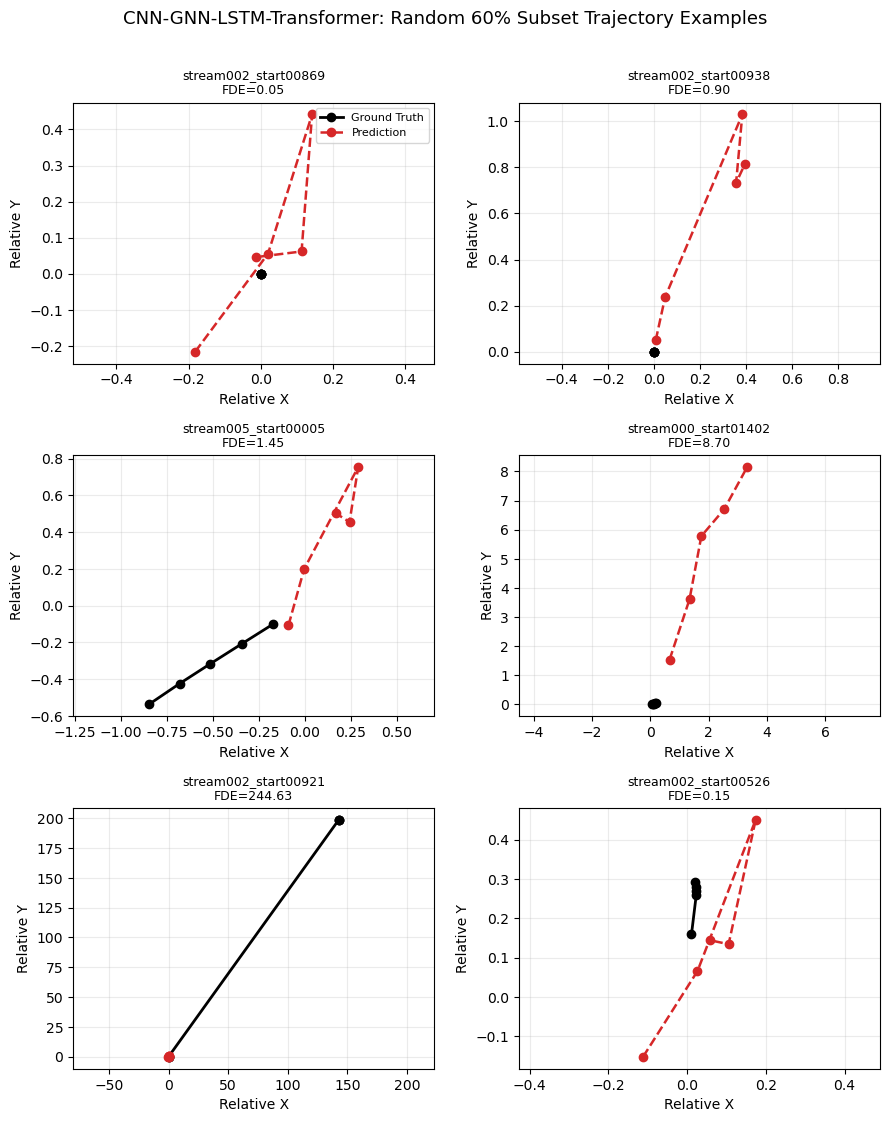

Saved: /home/basudeo/Documents/Thesis/04_model_evaluation/plots/best_model_random60_trajectory_panel.png


In [10]:
# Random 60% subset analysis for the best model using saved ground truth.
best_model_slug = 'cnn_gnn_lstm_transformer'
best_npz = RESULTS_ROOT / best_model_slug / 'latest_trajectory_predictions.npz'

if not best_npz.exists():
    print(f'Missing trajectory export for {best_model_slug}:', best_npz)
else:
    payload = np.load(best_npz, allow_pickle=False)
    sample_ids = payload['sample_ids'].astype(str)
    pred_future_xy = payload['pred_future_xy']
    true_future_xy = payload['true_future_xy']

    rng = np.random.default_rng(42)
    total = len(sample_ids)
    subset_size = max(1, int(round(0.60 * total)))
    subset_idx = np.sort(rng.choice(total, size=subset_size, replace=False))

    subset_pred = pred_future_xy[subset_idx]
    subset_true = true_future_xy[subset_idx]
    subset_ids = sample_ids[subset_idx]

    diff = subset_pred - subset_true
    subset_ade = float(np.linalg.norm(diff, axis=-1).mean())
    subset_fde = float(np.linalg.norm(diff[:, -1, :], axis=-1).mean())
    subset_rmse = float(np.sqrt((diff ** 2).sum(axis=-1).mean()))

    print('Best model:', best_model_slug)
    print('Subset size:', subset_size, 'out of', total)
    print('Subset ADE:', round(subset_ade, 4))
    print('Subset FDE:', round(subset_fde, 4))
    print('Subset RMSE:', round(subset_rmse, 4))

    # pick a diverse set of examples from the subset
    final_errors = np.linalg.norm(diff[:, -1, :], axis=-1)
    order = np.argsort(final_errors)
    picks = []
    if len(order) > 0:
        candidates = [order[0], order[len(order)//4], order[len(order)//2], order[(3*len(order))//4], order[-1]]
        seen = set()
        for idx in candidates:
            idx = int(idx)
            if idx not in seen and 0 <= idx < len(order):
                picks.append(idx)
                seen.add(idx)
        while len(picks) < min(6, len(order)):
            idx = int(order[len(picks)-1])
            if idx not in seen:
                picks.append(idx)
                seen.add(idx)

    ncols = 2
    nrows = int(np.ceil(max(1, len(picks)) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(9, 3.8 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax in axes:
        ax.axis('off')

    for ax, idx in zip(axes, picks):
        ax.axis('on')
        gt = subset_true[idx]
        pred = subset_pred[idx]
        ax.plot(gt[:, 0], gt[:, 1], '-o', color='black', linewidth=2, label='Ground Truth')
        ax.plot(pred[:, 0], pred[:, 1], '--o', color='tab:red', linewidth=1.8, label='Prediction')
        ax.set_title(f'{subset_ids[idx]}\nFDE={final_errors[idx]:.2f}', fontsize=9)
        ax.set_xlabel('Relative X')
        ax.set_ylabel('Relative Y')
        ax.grid(True, alpha=0.25)
        ax.axis('equal')

    if len(picks) > 0:
        axes[0].legend(fontsize=8)

    fig.suptitle('CNN-GNN-LSTM-Transformer: Random 60% Subset Trajectory Examples', fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    out_path = PLOTS_ROOT / 'best_model_random60_trajectory_panel.png'
    fig.savefig(out_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)


Best model: cnn_gnn_lstm_transformer
Full saved sample count: 1353
Full-set ADE: 16.1007
Full-set FDE: 21.8348
Full-set RMSE: 48.5245


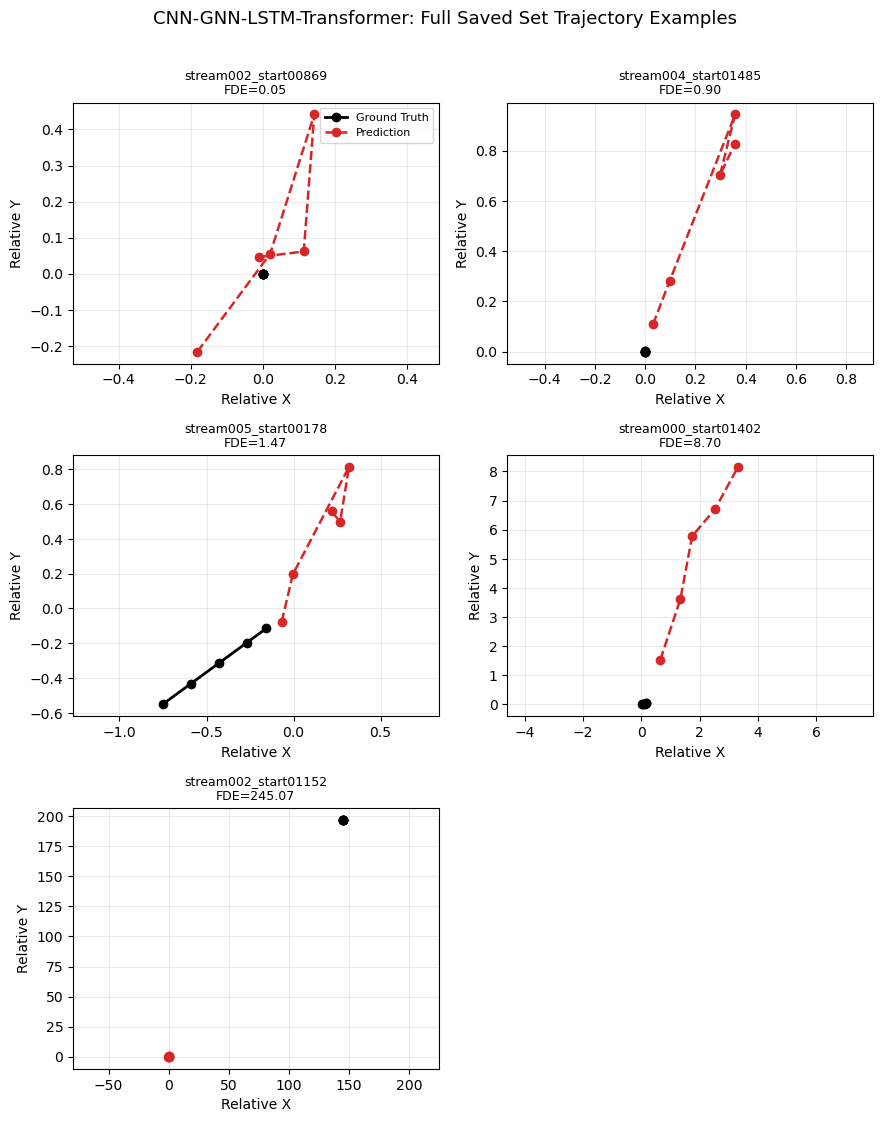

Saved: /home/basudeo/Documents/Thesis/04_model_evaluation/plots/best_model_fullset_trajectory_panel.png


In [11]:
# Full saved trajectory-set analysis for the best model.
best_model_slug = 'cnn_gnn_lstm_transformer'
best_npz = RESULTS_ROOT / best_model_slug / 'latest_trajectory_predictions.npz'

if not best_npz.exists():
    print(f'Missing trajectory export for {best_model_slug}:', best_npz)
else:
    payload = np.load(best_npz, allow_pickle=False)
    sample_ids = payload['sample_ids'].astype(str)
    pred_future_xy = payload['pred_future_xy']
    true_future_xy = payload['true_future_xy']

    diff = pred_future_xy - true_future_xy
    full_ade = float(np.linalg.norm(diff, axis=-1).mean())
    full_fde = float(np.linalg.norm(diff[:, -1, :], axis=-1).mean())
    full_rmse = float(np.sqrt((diff ** 2).sum(axis=-1).mean()))

    print('Best model:', best_model_slug)
    print('Full saved sample count:', len(sample_ids))
    print('Full-set ADE:', round(full_ade, 4))
    print('Full-set FDE:', round(full_fde, 4))
    print('Full-set RMSE:', round(full_rmse, 4))

    final_errors = np.linalg.norm(diff[:, -1, :], axis=-1)
    order = np.argsort(final_errors)
    candidate_indices = []
    for pos in [0, len(order)//4, len(order)//2, (3*len(order))//4, len(order)-1]:
        if len(order) == 0:
            break
        idx = int(order[pos])
        if idx not in candidate_indices:
            candidate_indices.append(idx)

    ncols = 2
    nrows = int(np.ceil(max(1, len(candidate_indices)) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(9, 3.8 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax in axes:
        ax.axis('off')

    for ax, idx in zip(axes, candidate_indices):
        ax.axis('on')
        gt = true_future_xy[idx]
        pred = pred_future_xy[idx]
        ax.plot(gt[:, 0], gt[:, 1], '-o', color='black', linewidth=2, label='Ground Truth')
        ax.plot(pred[:, 0], pred[:, 1], '--o', color='tab:red', linewidth=1.8, label='Prediction')
        ax.set_title(f'{sample_ids[idx]}\nFDE={final_errors[idx]:.2f}', fontsize=9)
        ax.set_xlabel('Relative X')
        ax.set_ylabel('Relative Y')
        ax.grid(True, alpha=0.25)
        ax.axis('equal')

    if len(candidate_indices) > 0:
        axes[0].legend(fontsize=8)

    fig.suptitle('CNN-GNN-LSTM-Transformer: Full Saved Set Trajectory Examples', fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    out_path = PLOTS_ROOT / 'best_model_fullset_trajectory_panel.png'
    fig.savefig(out_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)


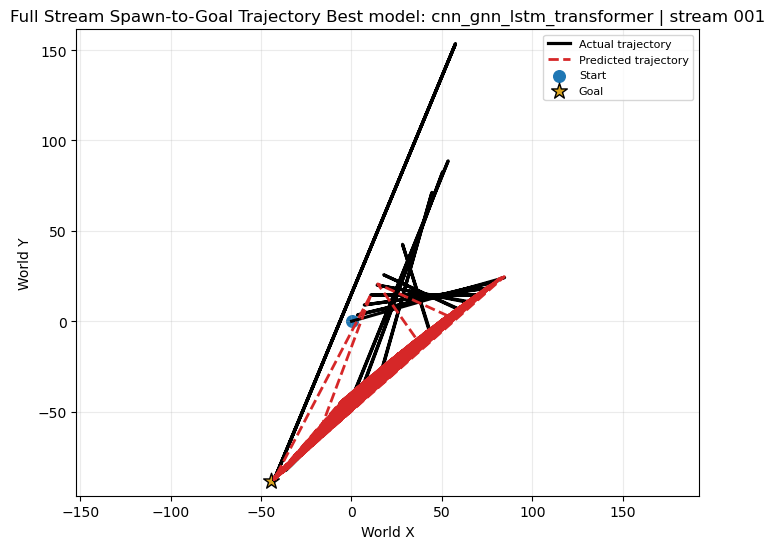

Saved: /home/basudeo/Documents/Thesis/04_model_evaluation/plots/best_model_full_stream_spawn_goal.png


In [12]:
# Full spawn-to-goal trajectory plot for one stream using the best model's rolling predictions.
from dataset_helper import build_sample_table, configure_helper, group_streams

DATASET_ROOT = PROJECT_ROOT.parent / '03_dataset' / 'husky_control_dataset'
configure_helper(
    dataset_root=DATASET_ROOT,
    original_dataset_root=DATASET_ROOT,
    results_root=RESULTS_ROOT,
    weights_root=EVAL_ROOT / 'model_weights',
)

best_model_slug = 'cnn_gnn_lstm_transformer'
display_names = globals().get('DISPLAY_NAMES', {best_model_slug: best_model_slug})
npz_path = RESULTS_ROOT / best_model_slug / 'latest_trajectory_predictions.npz'

if not npz_path.exists():
    print('Missing trajectory export:', npz_path)
else:
    payload = np.load(npz_path, allow_pickle=False)
    sample_ids = payload['sample_ids'].astype(str)
    pred_future_xy = payload['pred_future_xy']
    true_future_xy = payload['true_future_xy']

    streams = group_streams(DATASET_ROOT, allowed_labels=None, label_mapping=None)
    sample_table = build_sample_table(streams, past_len=10, future_len=5)
    sample_meta = {row['sample_id']: row for row in sample_table}

    # pick the longest available stream in the saved prediction set
    stream_counts = {}
    for sid in sample_ids:
        meta = sample_meta.get(sid)
        if meta is None:
            continue
        stream_counts[meta['stream_idx']] = stream_counts.get(meta['stream_idx'], 0) + 1

    if not stream_counts:
        print('Could not match saved sample_ids back to the dataset streams.')
    else:
        chosen_stream_idx = max(stream_counts, key=stream_counts.get)
        chosen_stream = streams[chosen_stream_idx]

        # full actual path from the recorded stream
        actual_xy = np.asarray([
            [float(frame['state']['x']), float(frame['state']['y'])]
            for frame in chosen_stream
            if frame.get('state') is not None
        ], dtype=np.float32)

        # rolling predicted future endpoints in absolute coordinates
        predicted_points = []
        for sid, pred_xy in zip(sample_ids, pred_future_xy):
            meta = sample_meta.get(sid)
            if meta is None or meta['stream_idx'] != chosen_stream_idx:
                continue
            anchor_frame = chosen_stream[meta['anchor_index']]
            anchor_state = anchor_frame['state']
            anchor_x = float(anchor_state['x'])
            anchor_y = float(anchor_state['y'])
            predicted_points.append([anchor_x + float(pred_xy[-1, 0]), anchor_y + float(pred_xy[-1, 1])])

        predicted_points = np.asarray(predicted_points, dtype=np.float32)

        start_pose = chosen_stream[0].get('start') or chosen_stream[0].get('state')
        goal_pose = chosen_stream[0].get('goal')

        fig, ax = plt.subplots(figsize=(7.2, 5.6))
        ax.plot(actual_xy[:, 0], actual_xy[:, 1], color='black', linewidth=2.3, label='Actual trajectory')
        if len(predicted_points) > 0:
            ax.plot(predicted_points[:, 0], predicted_points[:, 1], '--', color='tab:red', linewidth=2.0, label='Predicted trajectory')

        if start_pose is not None:
            ax.scatter([float(start_pose['x'])], [float(start_pose['y'])], marker='o', s=70, color='tab:blue', label='Start')
        if goal_pose is not None:
            ax.scatter([float(goal_pose['x'])], [float(goal_pose['y'])], marker='*', s=140, color='goldenrod', edgecolor='black', label='Goal')

        ax.set_title(f'Full Stream Spawn-to-Goal Trajectory Best model: {display_names.get(best_model_slug, best_model_slug)} | stream {chosen_stream_idx:03d}')
        ax.set_xlabel('World X')
        ax.set_ylabel('World Y')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)
        ax.axis('equal')
        fig.tight_layout()

        out_path = PLOTS_ROOT / 'best_model_full_stream_spawn_goal.png'
        fig.savefig(out_path, dpi=220, bbox_inches='tight')
        plt.show()
        print('Saved:', out_path)
